# FASE 3 — Entrenamiento

Entrenamos `DermaCNN` con:
- `CrossEntropyLoss` ponderada por clase (desbalance)
- Optimizador `AdamW` + scheduler `CosineAnnealingLR`
- Early stopping para evitar sobreajuste
- Checkpointing del mejor modelo (por F1-Macro en validación)
- Curvas de pérdida y métricas en tiempo real

## 1. Imports y configuración

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time, os
from tqdm import tqdm
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, confusion_matrix

# Módulos de fases anteriores
from pipeline import get_dataloaders, CLASS_NAMES, CLASS_WEIGHTS, NUM_CLASSES
from model import DermaCNN

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB


## 2. Hiperparámetros

In [2]:
# ── Hiperparámetros ──────────────────────────────────────
CONFIG = {
    'batch_size'    : 64,
    'num_epochs'    : 80,
    'lr'            : 1e-3,      # CAMBIO: más alto (antes 3e-4) para salir del plateau
    'weight_decay'  : 1e-5,      # CAMBIO: mucho menor (antes 1e-4) — menos regularización
    'dropout'       : 0.25,      # CAMBIO: menor (antes 0.4) — red pequeña, no necesita tanto
    'patience'      : 15,        # CAMBIO: más paciencia (antes 12)
    'min_delta'     : 1e-4,
    'checkpoint'    : 'best_model_v2.pth',
    'num_workers'   : 0,
}


for k, v in CONFIG.items():
    print(f'  {k:<16}: {v}')

  batch_size      : 64
  num_epochs      : 80
  lr              : 0.001
  weight_decay    : 1e-05
  dropout         : 0.25
  patience        : 15
  min_delta       : 0.0001
  checkpoint      : best_model_v2.pth
  num_workers     : 0


## 3. DataLoaders, Modelo, Loss, Optimizador

In [3]:
# ── CELDA B: Modelo v2 con label_smoothing ───────────────────
# (reemplaza la celda 3 del notebook original)

from pipeline import get_dataloaders, CLASS_NAMES, CLASS_WEIGHTS, NUM_CLASSES
from model import DermaCNN
import torch
import torch.nn as nn

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers']
)

model = DermaCNN(num_classes=NUM_CLASSES, dropout=CONFIG['dropout']).to(DEVICE)

class_weights_tensor = torch.FloatTensor(CLASS_WEIGHTS).to(DEVICE)

# CAMBIO: label_smoothing=0.1 evita que el modelo sea demasiado confiado
# Ayuda especialmente a las clases con pocas muestras
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=0.1
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay']
)

# CAMBIO: OneCycleLR en vez de CosineAnnealing
# Sube el LR al inicio (warm-up) y lo baja agresivamente al final
# Más efectivo cuando el LR inicial es más alto
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CONFIG['lr'],
    steps_per_epoch=len(train_loader),
    epochs=CONFIG['num_epochs'],
    pct_start=0.2,        # 20% de épocas en warm-up
    anneal_strategy='cos'
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {total_params:,}')
print(f'Device: {DEVICE}')
print('✅ Config v2 lista — ahora corre el loop de entrenamiento (celda 6)')
print()
print('Cambios aplicados:')
print('  pipeline.py  → pesos suavizados + augmentation conservadora')
print('  lr           → 1e-3  (antes 3e-4)')
print('  weight_decay → 1e-5  (antes 1e-4)')
print('  dropout      → 0.25  (antes 0.4)')
print('  criterion    → CrossEntropyLoss + label_smoothing=0.1')
print('  scheduler    → OneCycleLR  (antes CosineAnnealing)')
print('  patience     → 15    (antes 12)')

Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\isape\.medmnist\dermamnist.npz
Parámetros entrenables: 495,032
Device: cuda
✅ Config v2 lista — ahora corre el loop de entrenamiento (celda 6)

Cambios aplicados:
  pipeline.py  → pesos suavizados + augmentation conservadora
  lr           → 1e-3  (antes 3e-4)
  weight_decay → 1e-5  (antes 1e-4)
  dropout      → 0.25  (antes 0.4)
  criterion    → CrossEntropyLoss + label_smoothing=0.1
  scheduler    → OneCycleLR  (antes CosineAnnealing)
  patience     → 15    (antes 12)


## 4. Funciones de evaluación

In [4]:
def evaluate(model, loader, criterion, device):
    """
    Evalúa el modelo en un dataloader.
    Retorna: loss, accuracy, f1_macro, auc_macro, all_preds, all_labels, all_probs
    """
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []
    all_probs  = []   # probabilidades para AUC

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)

            probs  = torch.softmax(logits, dim=1)
            preds  = probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    avg_loss = total_loss / len(loader.dataset)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    auc      = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

    return avg_loss, acc, f1, auc, all_preds, all_labels, all_probs


print('✅ Función evaluate() definida')

✅ Función evaluate() definida


## 5. Early Stopping

In [5]:
class EarlyStopping:
    """
    Detiene el entrenamiento si la métrica de validación
    no mejora por `patience` épocas consecutivas.
    Guarda el mejor modelo automáticamente.
    """
    def __init__(self, patience=12, min_delta=1e-4, path='best_model.pth', verbose=True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.path       = path
        self.verbose    = verbose
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self._save(model, score)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'     EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stop = True
        else:
            self._save(model, score)
            self.best_score = score
            self.counter    = 0

    def _save(self, model, score):
        torch.save(model.state_dict(), self.path)
        if self.verbose:
            print(f'     ✅ Checkpoint guardado (F1={score:.4f})')


print('✅ EarlyStopping definido')

✅ EarlyStopping definido


## 6. Loop de Entrenamiento

In [6]:
# ── Historial de métricas ────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : [],
    'train_f1'  : [], 'val_f1'  : [],
    'train_auc' : [], 'val_auc' : [],
    'lr'        : [],
}

early_stopping = EarlyStopping(
    patience=CONFIG['patience'],
    min_delta=CONFIG['min_delta'],
    path=CONFIG['checkpoint']
)

print('Iniciando entrenamiento...')
print('='*70)
start_time = time.time()

for epoch in range(1, CONFIG['num_epochs'] + 1):

    # ── TRAIN ────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    train_preds, train_labels_ep = [], []

    pbar = tqdm(train_loader, desc=f'Epoch {epoch:02d}/{CONFIG["num_epochs"]}',
                leave=False, ncols=80)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()

        # Gradient clipping — evita explosión de gradientes
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels_ep.extend(labels.cpu().numpy())
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    scheduler.step()

    # Métricas de train
    t_loss = train_loss / len(train_loader.dataset)
    t_acc  = accuracy_score(train_labels_ep, train_preds)
    t_f1   = f1_score(train_labels_ep, train_preds, average='macro', zero_division=0)

    # ── VALIDACIÓN ───────────────────────────────────────
    v_loss, v_acc, v_f1, v_auc, _, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )

    current_lr = optimizer.param_groups[0]['lr']

    # Guardar historial
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['train_f1'].append(t_f1)
    history['val_f1'].append(v_f1)
    history['val_auc'].append(v_auc)
    history['lr'].append(current_lr)

    # Print resumen de época
    elapsed = (time.time() - start_time) / 60
    print(
        f'Ep {epoch:02d} | '
        f'TLoss={t_loss:.4f} Tacc={t_acc:.3f} TF1={t_f1:.3f} | '
        f'VLoss={v_loss:.4f} Vacc={v_acc:.3f} VF1={v_f1:.3f} VAUC={v_auc:.3f} | '
        f'LR={current_lr:.2e} | {elapsed:.1f}min'
    )

    # Early stopping (monitor: F1-Macro en validación)
    early_stopping(v_f1, model)
    if early_stopping.stop:
        print(f'\n⛔ Early stopping en época {epoch}')
        break

total_time = (time.time() - start_time) / 60
print('='*70)
print(f'Entrenamiento finalizado en {total_time:.1f} min')
print(f'Mejor F1-Macro en validación: {early_stopping.best_score:.4f}')

Iniciando entrenamiento...


Ep 01 | TLoss=1.9452 Tacc=0.397 TF1=0.257 | VLoss=1.9910 Vacc=0.511 VF1=0.276 VAUC=0.808 | LR=4.00e-05 | 0.7min
     ✅ Checkpoint guardado (F1=0.2760)


Ep 02 | TLoss=1.8455 Tacc=0.455 TF1=0.365 | VLoss=1.9516 Vacc=0.498 VF1=0.314 VAUC=0.822 | LR=4.00e-05 | 1.2min
     ✅ Checkpoint guardado (F1=0.3144)


Ep 03 | TLoss=1.7879 Tacc=0.464 TF1=0.391 | VLoss=1.9294 Vacc=0.492 VF1=0.315 VAUC=0.827 | LR=4.00e-05 | 1.8min
     ✅ Checkpoint guardado (F1=0.3153)


Ep 04 | TLoss=1.7364 Tacc=0.475 TF1=0.416 | VLoss=1.8991 Vacc=0.515 VF1=0.352 VAUC=0.846 | LR=4.00e-05 | 2.3min
     ✅ Checkpoint guardado (F1=0.3523)


...

Ep 66 | TLoss=1.1570 Tacc=0.682 TF1=0.696 | VLoss=1.6612 Vacc=0.626 VF1=0.471 VAUC=0.878 | LR=4.34e-05 | 36.2min
     EarlyStopping: 11/15


Ep 67 | TLoss=1.1506 Tacc=0.696 TF1=0.708 | VLoss=1.7133 Vacc=0.591 VF1=0.434 VAUC=0.857 | LR=4.35e-05 | 36.9min
     EarlyStopping: 12/15


Ep 68 | TLoss=1.1357 Tacc=0.698 TF1=0.710 | VLoss=1.7224 Vacc=0.569 VF1=0.427 VAUC=0.860 | LR=4.36e-05 | 37.8min
     EarlyStopping: 13/15


Ep 69 | TLoss=1.1486 Tacc=0.688 TF1=0.703 | VLoss=1.6886 Vacc=0.592 VF1=0.457 VAUC=0.865 | LR=4.37e-05 | 38.7min
     EarlyStopping: 14/15


Ep 70 | TLoss=1.1442 Tacc=0.697 TF1=0.707 | VLoss=1.6948 Vacc=0.604 VF1=0.467 VAUC=0.863 | LR=4.38e-05 | 39.5min
     EarlyStopping: 15/15

⛔ Early stopping en época 70
Entrenamiento finalizado en 39.5 min
Mejor F1-Macro en validación: 0.4879


## 7. Curvas de Entrenamiento

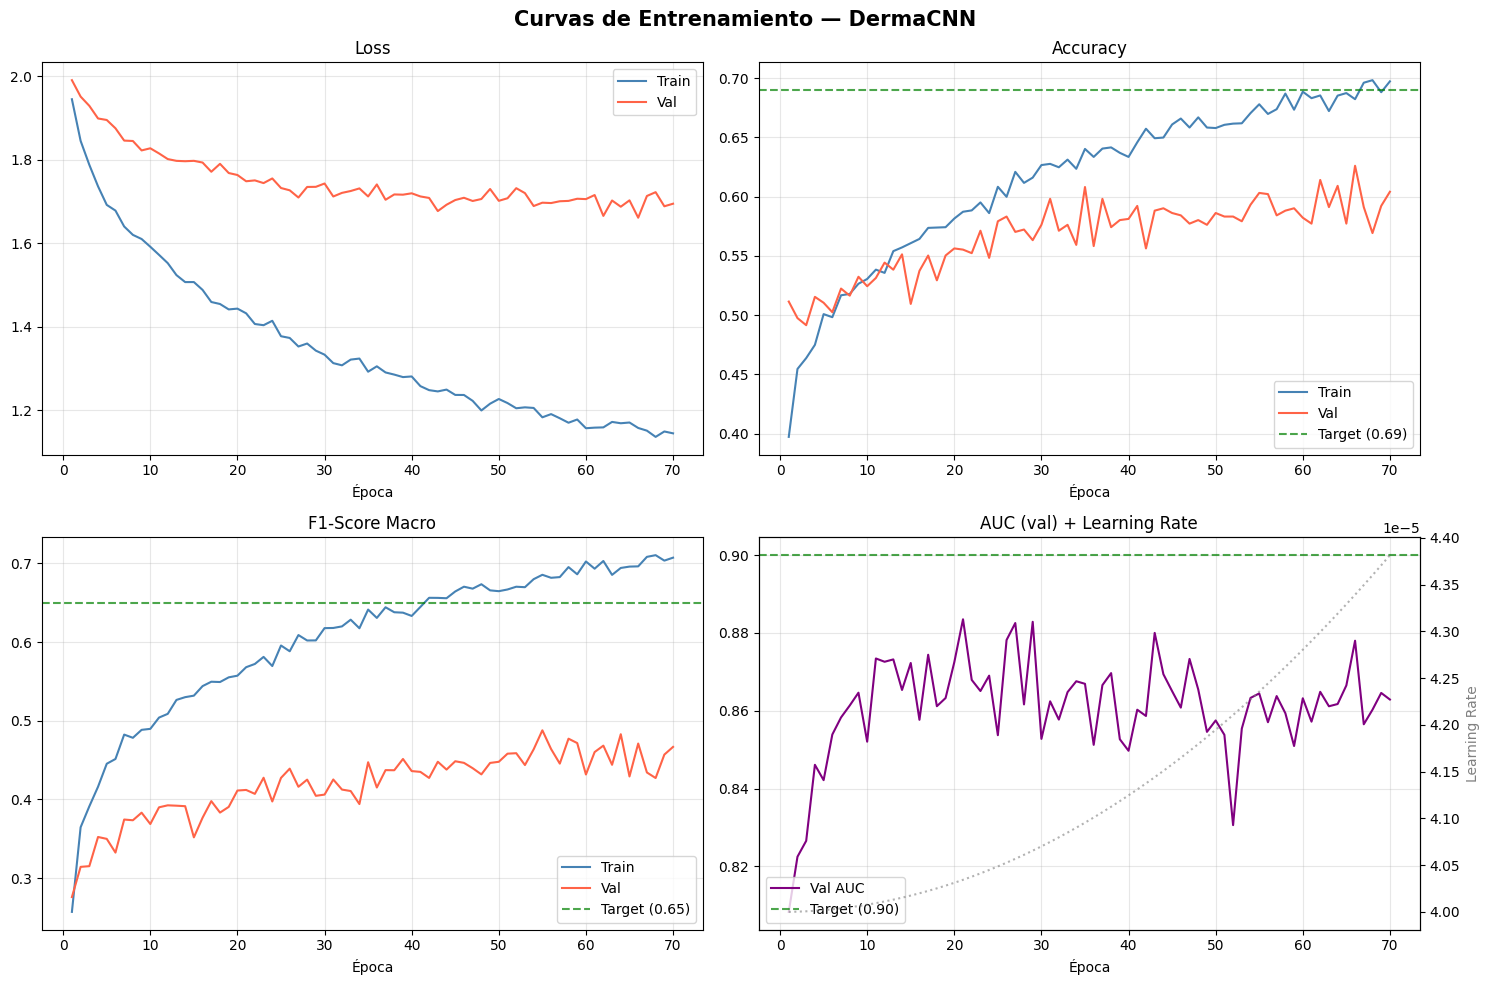

✅ Guardado: curvas_entrenamiento.png


In [11]:
epochs_ran = len(history['train_loss'])
ep_range   = range(1, epochs_ran + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Curvas de Entrenamiento — DermaCNN', fontsize=15, fontweight='bold')

# Loss
ax = axes[0][0]
ax.plot(ep_range, history['train_loss'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_loss'],   label='Val',   color='tomato')
ax.set_title('Loss')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# Accuracy
ax = axes[0][1]
ax.plot(ep_range, history['train_acc'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_acc'],   label='Val',   color='tomato')
ax.axhline(0.69, color='green', linestyle='--', alpha=0.7, label='Target (0.69)')
ax.set_title('Accuracy')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# F1-Macro
ax = axes[1][0]
ax.plot(ep_range, history['train_f1'], label='Train', color='steelblue')
ax.plot(ep_range, history['val_f1'],   label='Val',   color='tomato')
ax.axhline(0.65, color='green', linestyle='--', alpha=0.7, label='Target (0.65)')
ax.set_title('F1-Score Macro')
ax.set_xlabel('Época')
ax.legend()
ax.grid(alpha=0.3)

# AUC + LR
ax = axes[1][1]
ax.plot(ep_range, history['val_auc'], label='Val AUC', color='purple')
ax.axhline(0.90, color='green', linestyle='--', alpha=0.7, label='Target (0.90)')
ax2 = ax.twinx()
ax2.plot(ep_range, history['lr'], color='gray', linestyle=':', alpha=0.6, label='LR')
ax2.set_ylabel('Learning Rate', color='gray')
ax.set_title('AUC (val) + Learning Rate')
ax.set_xlabel('Época')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: curvas_entrenamiento.png')

## 8. Evaluación Final en Test Set

In [16]:
# Cargar el mejor modelo guardado
model.load_state_dict(torch.load(CONFIG['checkpoint'], map_location=DEVICE))
print(f'Modelo cargado desde: {CONFIG["checkpoint"]}')

# Evaluar en Test Set
test_loss, test_acc, test_f1, test_auc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

print()
print('='*50)
print('  RESULTADOS FINALES — TEST SET')
print('='*50)

TARGETS = {'Accuracy': 0.69, 'AUC': 0.90, 'F1-Macro': 0.65}
results  = {'Accuracy': test_acc, 'AUC': test_auc, 'F1-Macro': test_f1}

for metric, value in results.items():
    target = TARGETS[metric]
    status = 'ok -' if value >= target else 'X'
    print(f'  {status} {metric:<12}: {value:.4f}  (target ≥ {target})')

print('='*50)
all_pass = all(results[m] >= TARGETS[m] for m in TARGETS)
print(f'  {"APROBADO" if all_pass else "AÚN NO CUMPLE"}')
print('='*50)

C:\Users\isape\AppData\Local\Temp\ipykernel_18960\3200187190.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CONFIG['checkpoint'], map_l

Modelo cargado desde: best_model_v2.pth

  RESULTADOS FINALES — TEST SET
  X Accuracy    : 0.6090  (target ≥ 0.69)
  ok - AUC         : 0.9045  (target ≥ 0.9)
  X F1-Macro    : 0.4877  (target ≥ 0.65)
  AÚN NO CUMPLE


## 9. Matriz de Confusión

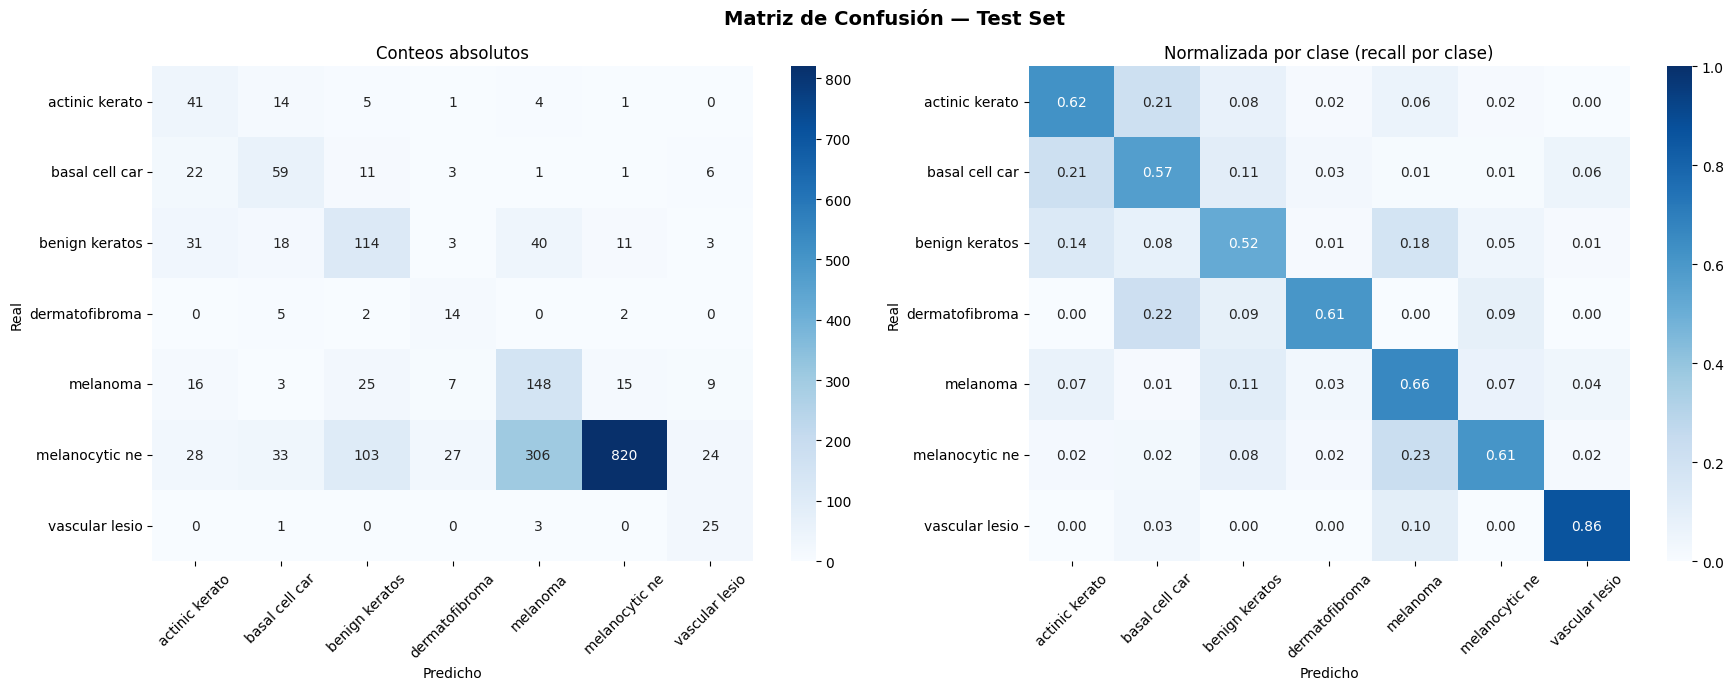

✅ Guardado: confusion_matrix.png

Reporte por clase:
                                                 precision    recall  f1-score   support

actinic keratoses and intraepithelial carcinoma       0.30      0.62      0.40        66
                           basal cell carcinoma       0.44      0.57      0.50       103
                  benign keratosis-like lesions       0.44      0.52      0.47       220
                                 dermatofibroma       0.25      0.61      0.36        23
                                       melanoma       0.29      0.66      0.41       223
                               melanocytic nevi       0.96      0.61      0.75      1341
                               vascular lesions       0.37      0.86      0.52        29

                                       accuracy                           0.61      2005
                                      macro avg       0.44      0.64      0.49      2005
                                   weighted avg       0

In [13]:
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizada por fila

short_names = [n[:14] for n in CLASS_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matriz de Confusión — Test Set', fontsize=14, fontweight='bold')

# Absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=axes[0])
axes[0].set_title('Conteos absolutos')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalizada por clase (recall por clase)')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: confusion_matrix.png')

# Métricas por clase
from sklearn.metrics import classification_report
print('\nReporte por clase:')
print(classification_report(test_labels, test_preds,
      target_names=CLASS_NAMES, zero_division=0))

## 11. Guardar artefactos para Fase 4

In [14]:
import pickle

# Guardar resultados del test para usar en Fase 4 (Grad-CAM)
artefactos = {
    'test_preds' : test_preds,
    'test_labels': test_labels,
    'test_probs' : test_probs,
    'history'    : history,
    'test_acc'   : test_acc,
    'test_f1'    : test_f1,
    'test_auc'   : test_auc,
}

with open('test_results.pkl', 'wb') as f:
    pickle.dump(artefactos, f)

print('Archivos listos para Fase 4:')
print('  best_model.pth    — pesos del mejor modelo')
print('  test_results.pkl  — métricas y predicciones del test set')
print('  curvas_entrenamiento.png — para el reporte IEEE')
print('  confusion_matrix.png    — para el reporte IEEE')
print()
print('✅ Fase 3 completa — listo para Fase 4: Grad-CAM')

Archivos listos para Fase 4:
  best_model.pth    — pesos del mejor modelo
  test_results.pkl  — métricas y predicciones del test set
  curvas_entrenamiento.png — para el reporte IEEE
  confusion_matrix.png    — para el reporte IEEE

✅ Fase 3 completa — listo para Fase 4: Grad-CAM


## ✅ Resumen Fase 3

| Decisión | Justificación |
|----------|---------------|
| `AdamW` | Mejor regularización que Adam estándar (weight decay separado) |
| `CosineAnnealingLR` | Evita mínimos locales — baja LR suavemente |
| `CrossEntropyLoss(weight=...)` | Segunda línea de defensa contra desbalance |
| Gradient clipping (norm=1.0) | Evita explosión de gradientes en las fusiones no lineales |
| Early stopping en F1-Macro | Métrica más representativa para datasets desbalanceados |
| Checkpoint del mejor modelo | Evita sobreajuste al final del entrenamiento |

**Siguiente paso → Fase 4: Evaluación + Grad-CAM (XAI)**